# **Implementación del caso de 10 Qubits.**

In [1]:
%load_ext autoreload
%autoreload 2

from modules import schnorr_lattice as sl
from modules import qaoa as q
from modules import utils

import numpy as np
import matplotlib.pyplot as plt
from qiskit.visualization import plot_histogram

In [2]:
N10 = 261980999226229

## **Implementación con 8 Qubits**

In [3]:
seed = 51

In [4]:
eightQubit = sl.schnorrCVP(N10, 4, 1, seed)

El numero de bits de N = 261980999226229 es m = 48
La dimension del reticulo que vamos a tratar es n = 8
La cota smooth que vamos a tomar: 128


In [5]:
cvpinstance = eightQubit.generate_cvp(10)

B = 
[ 2 0 0 0 0 0 0 0  6931 ]
[ 0 3 0 0 0 0 0 0 10986 ]
[ 0 0 2 0 0 0 0 0 16094 ]
[ 0 0 0 4 0 0 0 0 19459 ]
[ 0 0 0 0 1 0 0 0 23979 ]
[ 0 0 0 0 0 3 0 0 25649 ]
[ 0 0 0 0 0 0 1 0 28332 ]
[ 0 0 0 0 0 0 0 4 29444 ]
t = 
(0, 0, 0, 0, 0, 0, 0, 0, 331993)


In [6]:
cvpResult = eightQubit.babai_algorithm(cvpinstance, delta = 0.99)
print(f'D = \n{cvpResult.D}\n')
print(f'b_op = \n{cvpResult.b_op}\n')
print(f'res_vector = \n{cvpResult.res_vector}\n')
print(f'step_sign = \n{cvpResult.step_sign}\n')
print(f'weights = \n{cvpResult.weight}\n')

D = 
[  2  0 -4 -4  3  0 -2  4  1 ]
[  0 -3  4  0 -2  3 -1  4  5 ]
[  6 -3  0  0 -4  0  2  4 -1 ]
[  4  0 -2  0 -2  6  1 -4 -4 ]
[ -4  0  6  4 -1  3 -3  4 -3 ]
[  2 -6  6  0  2 -3 -3  4 -2 ]
[  2 -6 -4  4  1 -3  0  4  4 ]
[ -8 -3  0  0 -3  3  3  0 -2 ]

b_op = 
[     2      0      2      0      0      3     10      0 331994]

res_vector = 
[ -2   0  -2   0   0  -3 -10   0  -1]

step_sign = 
[ 1 -1 -1 -1  1  1  1 -1]

weights = 
(-8765, 35541, -13511, -8003, -15327, -12503, 6562, -10148)



In [7]:
qubo8 = q.define_qubo(cvpResult.D, cvpResult.res_vector, cvpResult.step_sign, eightQubit.n)
print(qubo8.prettyprint())

Hc8, offset8 = q.define_hamiltonian(qubo8)
print(f'Offset = {offset8}')
print(f'Hamiltonian = {Hc8}')


Problem name: quboProblem

Minimize
  66*z_0^2 - 2*z_0*z_1 - 22*z_0*z_2 + 24*z_0*z_3 - 64*z_0*z_4 + 12*z_0*z_5
  + 54*z_0*z_6 + 66*z_0*z_7 + 80*z_1^2 + 52*z_1*z_2 - 46*z_1*z_3 - 78*z_1*z_4
  - 76*z_1*z_5 - 54*z_1*z_6 + 22*z_1*z_7 + 82*z_2^2 + 44*z_2*z_3 + 14*z_2*z_4
  - 68*z_2*z_5 - 76*z_2*z_6 - 38*z_2*z_7 + 93*z_3^2 + 30*z_3*z_4 + 74*z_3*z_5
  + 72*z_3*z_6 + 6*z_3*z_7 + 112*z_4^2 + 96*z_4*z_5 - 44*z_4*z_6 - 82*z_4*z_7
  + 118*z_5^2 + 70*z_5*z_6 + 36*z_5*z_7 + 114*z_6^2 + 36*z_6*z_7 + 104*z_7^2
  - 46*z_0 - 24*z_1 - 62*z_2 - 56*z_3 - 40*z_4 - 50*z_5 - 18*z_6 - 42*z_7 + 118

Subject to
  No constraints

  Binary variables (8)
    z_0 z_1 z_2 z_3 z_4 z_5 z_6 z_7

Offset = 348.0
Hamiltonian = SparsePauliOp(['IIIIIIIZ', 'IIIIIZII', 'IIIIZIII', 'IIIZIIII', 'IIZIIIII', 'IZIIIIII', 'ZIIIIIII', 'IIIIIIZI', 'IIIIIIZZ', 'IIIIIZIZ', 'IIIIZIIZ', 'IIIZIIIZ', 'IIZIIIIZ', 'IZIIIIIZ', 'ZIIIIIIZ', 'IIIIIZZI', 'IIIIZIZI', 'IIIZIIZI', 'IIZIIIZI', 'IZIIIIZI', 'ZIIIIIZI', 'IIIIZZII', 'IIIZIZII', 'IIZIIZII'

In [8]:
circuit8 = q.construct_circuit(Hc8, reps = 1)
print(circuit8)

     ┌───┐ ┌────────────────┐                                           »
q_0: ┤ H ├─┤ Rz((-54)*γ[0]) ├─■───────────■────────────────■────────────»
     ├───┤ └┬─────────────┬─┘ │ZZ(-γ[0])  │                │            »
q_1: ┤ H ├──┤ Rz(35*γ[0]) ├───■───────────┼────────────────┼────────────»
     ├───┤  ├─────────────┤               │ZZ((-11)*γ[0])  │            »
q_2: ┤ H ├──┤ Rz(27*γ[0]) ├───────────────■────────────────┼────────────»
     ├───┤┌─┴─────────────┴─┐                              │ZZ(12*γ[0]) »
q_3: ┤ H ├┤ Rz((-139)*γ[0]) ├──────────────────────────────■────────────»
     ├───┤└┬───────────────┬┘                                           »
q_4: ┤ H ├─┤ Rz((-8)*γ[0]) ├────────────────────────────────────────────»
     ├───┤┌┴───────────────┴┐                                           »
q_5: ┤ H ├┤ Rz((-140)*γ[0]) ├───────────────────────────────────────────»
     ├───┤├─────────────────┤                                           »
q_6: ┤ H ├┤ Rz((-125)*γ[0]) ├─────────

In [9]:
x0 = np.asarray([0.0]*circuit8.num_parameters)
_, optParameters8 = q.qaoa_algorithm(circuit8, Hc8, x0)

In [10]:
for param in optParameters8.items():
    print(f'{param[0]} = {param[1]}')

β[0] = -0.4799726604811829
γ[0] = 0.008447652215877989


In [11]:
results8 = q.sample_from_parameters(circuit8, optParameters8, shots = 10_000)
print(len(results8))
for bitstring, count in results8.items():
    print(f"Bistring: {bitstring} -> Counts: {count}")

214
Bistring: 00000100 -> Counts: 402
Bistring: 00010011 -> Counts: 370
Bistring: 00000000 -> Counts: 295
Bistring: 00100110 -> Counts: 290
Bistring: 00010010 -> Counts: 276
Bistring: 00000010 -> Counts: 272
Bistring: 00000101 -> Counts: 254
Bistring: 01010110 -> Counts: 237
Bistring: 00100100 -> Counts: 220
Bistring: 00001010 -> Counts: 213
Bistring: 00000110 -> Counts: 198
Bistring: 00010111 -> Counts: 195
Bistring: 10000100 -> Counts: 189
Bistring: 01010010 -> Counts: 188
Bistring: 00100010 -> Counts: 186
Bistring: 00010101 -> Counts: 183
Bistring: 10010100 -> Counts: 180
Bistring: 10010110 -> Counts: 178
Bistring: 10010010 -> Counts: 175
Bistring: 01010111 -> Counts: 173
Bistring: 11010110 -> Counts: 173
Bistring: 00100111 -> Counts: 169
Bistring: 10010101 -> Counts: 150
Bistring: 01000110 -> Counts: 150
Bistring: 00001000 -> Counts: 148
Bistring: 00010110 -> Counts: 139
Bistring: 00010001 -> Counts: 136
Bistring: 00000011 -> Counts: 134
Bistring: 01000100 -> Counts: 132
Bistring: 

In [12]:
nD8 = sl.integer_to_matrix(cvpResult.D)
vnew8 = sl.bitstring2latticeVectors(nD8, results8.keys(), cvpResult.step_sign, cvpResult.b_op)
for vect8 in vnew8:
    print(vect8)

[    -4      3      2      0      4      3      8     -4 331995]
[     0      3      0      0      4      3      6      4 331987]
[     2      0      2      0      0      3     10      0 331994]
[    -2      0      4      0      8     -3      6     -4 331988]
[    -2      3      4      4      1      3      8      0 331986]
[     2      3     -2      0      2      0     11     -4 331989]
[    -2      3     -2     -4      7      3      6      0 331996]
[    -6      0      0      8      6      0      6      0 331991]
[    -2     -3      8      0      6      0      5      0 331993]
[    -2      3      0      0      4     -6     10      0 331993]
[    -4      6     -2      0      6      0      9     -8 331990]
[    -6      6      0      0      8      3      4      0 331988]
[     4      6      2      0      7      0      5     -4 331997]
[     0     -3      0      8      2      0      8      4 331990]
[     4     -3      4      0      4     -3      8      0 331987]
[    -6      3      4    

In [13]:
distances8 = utils.get_distances(vnew8, cvpinstance.t)
for dist in distances8:
    print(dist)

11.74734012447073
11.045361017187261
10.862780491200215
13.038404810405298
12.96148139681572
13.19090595827292
11.661903789690601
13.2664991614216
11.74734012447073
12.84523257866513
15.684387141358123
13.638181696985855
12.727922061357855
12.884098726725126
12.884098726725126
12.569805089976535
12.884098726725126
14.7648230602334
13.038404810405298
12.727922061357855
13.2664991614216
13.341664064126334
12.884098726725126
14.560219778561036
12.449899597988733
15.937377450509228
12.083045973594572
13.856406460551018
12.569805089976535
11.74734012447073
12.922847983320086
13.74772708486752
14.696938456699069
12.165525060596439
15.556349186104045
13.038404810405298
14.352700094407323
13.341664064126334
14.7648230602334
14.035668847618199
14.142135623730951
13.784048752090222
14.966629547095765
14.0
13.784048752090222
14.798648586948742
13.416407864998739
14.071247279470288
15.874507866387544
13.711309200802088
16.76305461424021
14.38749456993816
16.55294535724685
17.08800749063506
13.1909

In [14]:
nB8 = sl.integer_to_matrix(cvpinstance.B)
uv_pairs8 = sl.vectors2uv_pairs(nB8, vnew8, eightQubit.n)
print(uv_pairs8)

[[19915752615267795 76]
 [261868027467189 1]
 [262079207058370 1]
 [129352557022507225 494]
 [523704989883075 2]
 [24881396719341558 95]
 [18344544450464661 70]
 [2095297617885241 8]
 [1572102054235625 6]
 [88548500089421427 338]
 [1890770913674116353 7220]
 [2094705767700117 8]
 [4980419307818460 19]
 [785826051486091 3]
 [10213206469368100 39]
 [2096063541654225 8]
 [262070340406875 1]
 [4976110986617925 19]
 [261930391846200 1]
 [26192773830301463 100]
 [3405871519729602 13]
 [23829516041101331 91]
 [262085885854650 1]
 [16176595594767439909 61750]
 [6815838201665075 26]
 [79594097822264025 304]
 [262037768531825 1]
 [229184353172620164 875]
 [7864168981413437 30]
 [9173316356123348 35]
 [13620692197897455 52]
 [27239768591429625 104]
 [261916113620898 1]
 [5502683577794425 21]
 [8708014138755186387 33250]
 [262100173335000 1]
 [398405875629322253 1521]
 [262159937104450 1]
 [1047223518265375 4]
 [44277791974589250 169]
 [6289967326417775 24]
 [5764488970638125 22]
 [419187843011437

In [15]:
sr_pairs8 = sl.uv_pairs2sr_pairs(uv_pairs8, eightQubit)
print(sr_pairs8)

[]


In [16]:
probs8 = utils.get_probs(results8.values(), shots = 10_000)

In [17]:
utils.prettyprint(vnew8, distances8, probs8, cvpResult.b_op, cvpResult.res_vector)

Vector más corto por algoritmo de Babai: 
b_op = [     2      0      2      0      0      3     10      0 331994]

El vector residual 
t - b_op = [ -2   0  -2   0   0  -3 -10   0  -1]

La distancia |t - b_op| = 10.863

0: Prob = 0.04020
	vnew = [    -4      3      2      0      4      3      8     -4 331995] con distancia: 11.747
1: Prob = 0.03700
	vnew = [     0      3      0      0      4      3      6      4 331987] con distancia: 11.045
2: Prob = 0.02950
	vnew = [     2      0      2      0      0      3     10      0 331994] con distancia: 10.863
3: Prob = 0.02900
	vnew = [    -2      0      4      0      8     -3      6     -4 331988] con distancia: 13.038
4: Prob = 0.02760
	vnew = [    -2      3      4      4      1      3      8      0 331986] con distancia: 12.961
5: Prob = 0.02720
	vnew = [     2      3     -2      0      2      0     11     -4 331989] con distancia: 13.191
6: Prob = 0.02540
	vnew = [    -2      3     -2     -4      7      3      6      0 331996] con distanci

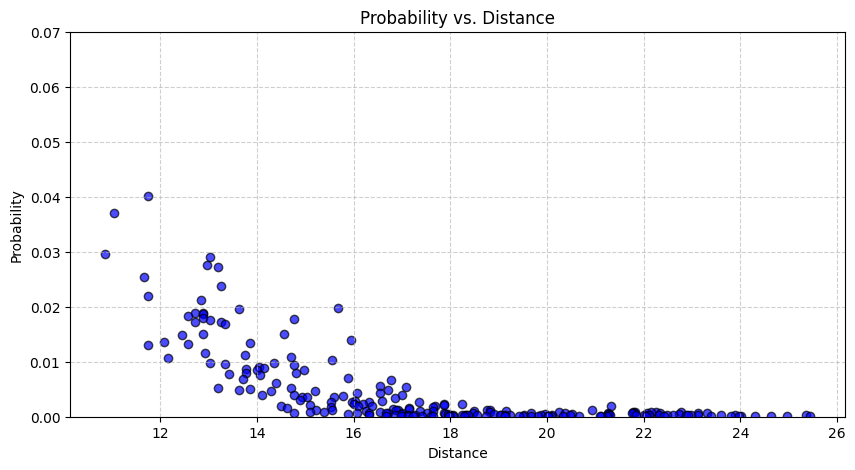

In [18]:
plt.figure(figsize=(10, 5))

# Creating the scatter plot
plt.scatter(distances8, probs8, color='blue', edgecolors='black', alpha=0.7)

# Adding labels and title
plt.xlabel('Distance')
plt.ylabel('Probability')
plt.title('Probability vs. Distance')

# Setting y-axis limit since you mentioned probs are <= 0.2
plt.ylim(0, 0.07) 

plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

## **Implementación con 10 Qubits**

In [19]:
seed = 42

In [20]:
tenQubit = sl.schnorrCVP(N10, 4, 1, seed, verbose = False)

In [21]:
tenQubit.set_n(10)
tenQubit.set_smoothbound(200)

print(f'La dimension del retículo que vamos a tratar es n = {tenQubit.get_n()}')
print(f'La cota smooth que vamos a tomar es Smooth Bound = {tenQubit.get_smoothbound()}')

La dimension del retículo que vamos a tratar es n = 10
La cota smooth que vamos a tomar es Smooth Bound = 200


In [22]:
cvpinstance = tenQubit.generate_cvp(10)

B = 
[ 5 0 0 0 0 0 0 0 0 0  6931 ]
[ 0 1 0 0 0 0 0 0 0 0 10986 ]
[ 0 0 3 0 0 0 0 0 0 0 16094 ]
[ 0 0 0 1 0 0 0 0 0 0 19459 ]
[ 0 0 0 0 4 0 0 0 0 0 23979 ]
[ 0 0 0 0 0 2 0 0 0 0 25649 ]
[ 0 0 0 0 0 0 5 0 0 0 28332 ]
[ 0 0 0 0 0 0 0 3 0 0 29444 ]
[ 0 0 0 0 0 0 0 0 2 0 31355 ]
[ 0 0 0 0 0 0 0 0 0 4 33673 ]
t = 
(0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 331993)


In [23]:
cvpResult = tenQubit.babai_algorithm(cvpinstance, delta = 0.75)
print(f'D10 = \n{cvpResult.D}\n')
print(f'b_op10 = \n{cvpResult.b_op}\n')
print(f'res_vector10 = \n{cvpResult.res_vector}\n')
print(f'step_sign10 = \n{cvpResult.step_sign}\n')
print(f'weights10 = \n{cvpResult.weight}\n')

D10 = 
[  0  1  3 -1  0  2  0  3 -4  0  4 ]
[  5  3 -3  2  0  0  0  0 -4  0  3 ]
[  0  4 -3  1 -4 -2  0  0 -2  4 -1 ]
[  0  4 -3 -1  0  4 -5  0 -2  0  2 ]
[  0  1 -3 -3  0 -2  5  3  2  0 -3 ]
[  0 -1 -6  0  0 -4  0  3  2  4  0 ]
[ -5 -2  3  4  0  0  0  0 -2 -4 -1 ]
[  0  5  0  3  0 -4 -5  0  0 -4  4 ]
[ -5  4  0 -2  0  0  0 -3  2  0  6 ]
[ -5  2  0  1  4  0  0 -3 -4  4 -2 ]

b_op10 = 
[     0      1      0      6      0      4      0      6      6      0
 331991]

res_vector10 = 
[ 0 -1  0 -6  0 -4  0 -6 -6  0  2]

step_sign10 = 
[ 1  1  1 -1 -1 -1 -1  1  1  1]

weights10 = 
(15714, 20489, -11636, -10577, -17862, 19313, 3326, -7285, 28799, -11636)



In [24]:
qubo10 = q.define_qubo(cvpResult.D, cvpResult.res_vector, cvpResult.step_sign, tenQubit.n)
print(qubo10.prettyprint())


Hc10, offset10 = q.define_hamiltonian(qubo10)
print(f'Offset = {offset10}')
print(f'Hamiltonian = \n{Hc10}')

Problem name: quboProblem

Minimize
  56*z_0^2 + 40*z_0*z_1 - 12*z_0*z_2 - 40*z_0*z_3 + 40*z_0*z_4 + 52*z_0*z_5
  - 14*z_0*z_6 + 20*z_0*z_7 + 26*z_0*z_8 + 72*z_1^2 + 56*z_1*z_2 - 66*z_1*z_3
  + 22*z_1*z_4 - 14*z_1*z_5 + 54*z_1*z_6 + 66*z_1*z_7 - 14*z_1*z_8 - 14*z_1*z_9
  + 67*z_2^2 - 36*z_2*z_3 - 26*z_2*z_4 - 68*z_2*z_5 + 48*z_2*z_6 + 22*z_2*z_7
  + 8*z_2*z_8 + 38*z_2*z_9 + 75*z_3^2 - 54*z_3*z_4 - 12*z_3*z_5 - 38*z_3*z_6
  - 68*z_3*z_7 - 52*z_3*z_8 - 22*z_3*z_9 + 70*z_4^2 + 76*z_4*z_5 - 48*z_4*z_6
  + 66*z_4*z_7 + 26*z_4*z_8 + 24*z_4*z_9 + 82*z_5^2 - 72*z_5*z_6 + 10*z_5*z_7
  + 18*z_5*z_8 + 6*z_5*z_9 + 75*z_6^2 - 28*z_6*z_7 + 2*z_6*z_8 - 38*z_6*z_9
  + 107*z_7^2 + 76*z_7*z_8 - 22*z_7*z_9 + 94*z_8^2 + 40*z_8*z_9 + 91*z_9^2
  - 22*z_0 - 30*z_1 - 16*z_2 + 4*z_3 - 22*z_4 - 26*z_5 - 24*z_6 - 2*z_7 - 52*z_8
  - 60*z_9 + 129

Subject to
  No constraints

  Binary variables (10)
    z_0 z_1 z_2 z_3 z_4 z_5 z_6 z_7 z_8 z_9

Offset = 418.0
Hamiltonian = 
SparsePauliOp(['IIIIIIIIIZ', 'IIIIIIIIZI'

In [25]:
circuit10 = q.construct_circuit(Hc10, reps= 1)
print(circuit10)

     ┌───┐ ┌────────────────┐                                               »
q_0: ┤ H ├─┤ Rz((-90)*γ[0]) ├─■─────────────■───────────────■───────────────»
     ├───┤┌┴────────────────┤ │ZZ(20*γ[0])  │               │               »
q_1: ┤ H ├┤ Rz((-107)*γ[0]) ├─■─────────────┼───────────────┼───────────────»
     ├───┤└┬────────────────┤               │ZZ((-6)*γ[0])  │               »
q_2: ┤ H ├─┤ Rz((-66)*γ[0]) ├───────────────■───────────────┼───────────────»
     ├───┤ └┬──────────────┬┘                               │ZZ((-20)*γ[0]) »
q_3: ┤ H ├──┤ Rz(115*γ[0]) ├────────────────────────────────■───────────────»
     ├───┤┌─┴──────────────┴┐                                               »
q_4: ┤ H ├┤ Rz((-111)*γ[0]) ├───────────────────────────────────────────────»
     ├───┤└┬────────────────┤                                               »
q_5: ┤ H ├─┤ Rz((-54)*γ[0]) ├───────────────────────────────────────────────»
     ├───┤ └┬─────────────┬─┘                                   

In [26]:
x0 = np.asarray([0.0]*circuit10.num_parameters)
monitor, optParameters10 = q.qaoa_algorithm(circuit10, Hc10, x0)

In [27]:
print(f'Iteraciones = {monitor.iteration}')
print(f'Evolucion: ')
for angles, value in zip(monitor.parameters, monitor.evaluation):
    print(f'{angles}: {value}')

Iteraciones = 53
Evolucion: 
[0.       0.000125]: -2.87122214025215e-14
[-0.00025    0.0003125]: -0.010549595569733169
[-0.00025    0.0003125]: -0.010549595569733169
[-0.00075  0.0005 ]: -0.0505926211114497
[-0.001       0.00084375]: -0.113528964238128
[-0.002125    0.00139063]: -0.3947715138970582
[-0.0031875   0.00235156]: -0.9805760958042883
[-0.00596875  0.00392578]: -2.8924967953977405
[-0.00948438  0.00663477]: -6.563676254571355
[-0.01680469  0.0111377 ]: -12.048022841224112
[-0.01680469  0.0111377 ]: -12.048022841224112
[-0.01680469  0.0111377 ]: -12.048022841224112
[-0.01680469  0.0111377 ]: -12.048022841224112
[-0.01731641  0.01124756]: -12.346093372883665
[-0.01894629  0.01257458]: -12.41417034375277
[-0.01945801  0.01268445]: -12.635681616778692
[-0.01945801  0.01268445]: -12.635681616778692
[-0.01868335  0.01178531]: -12.924783633247431
[-0.02069348  0.01282756]: -13.271210084007011
[-0.02014923  0.01155041]: -14.113141321001367
[-0.02389737  0.01299633]: -15.0735913824621

In [28]:
for param in optParameters10.items():
    print(f'{param[0]} = {param[1]}')

β[0] = -0.5090286975996214
γ[0] = 0.008623538651799493


In [29]:
results10 = q.sample_from_parameters(circuit10, optParameters10, shots = 10_000)
print(len(results10))
for bitstring, count in results10.items():
    print(f"Bistring: {bitstring} -> Counts: {count}")

596
Bistring: 1001001000 -> Counts: 234
Bistring: 0000001000 -> Counts: 206
Bistring: 0001001000 -> Counts: 199
Bistring: 1001101000 -> Counts: 198
Bistring: 0000000000 -> Counts: 188
Bistring: 0001101000 -> Counts: 161
Bistring: 0001011000 -> Counts: 160
Bistring: 0001101100 -> Counts: 157
Bistring: 1001001001 -> Counts: 153
Bistring: 1000001000 -> Counts: 142
Bistring: 1001011000 -> Counts: 137
Bistring: 1000001010 -> Counts: 134
Bistring: 0000001010 -> Counts: 131
Bistring: 0001001001 -> Counts: 127
Bistring: 0000001100 -> Counts: 125
Bistring: 0100001010 -> Counts: 121
Bistring: 1000000000 -> Counts: 118
Bistring: 0000101100 -> Counts: 117
Bistring: 1011001000 -> Counts: 115
Bistring: 0000001001 -> Counts: 114
Bistring: 0101001000 -> Counts: 112
Bistring: 0001000000 -> Counts: 110
Bistring: 0000001101 -> Counts: 110
Bistring: 0100001000 -> Counts: 109
Bistring: 0001100000 -> Counts: 105
Bistring: 1011101000 -> Counts: 103
Bistring: 0001011100 -> Counts: 96
Bistring: 1001101010 -> C

In [30]:
nD10 = sl.integer_to_matrix(cvpResult.D)
vnew10 = sl.bitstring2latticeVectors(nD10, results10.keys(), cvpResult.step_sign, cvpResult.b_op)
for vect10 in vnew10:
    print(vect10)

[     0      1      0      4      4      0      5      3      6      8
 331988]
[     0     -3      3      7      0      0      5      6      8      0
 331989]
[     5     -1      0      3      0      0      5      6     10      4
 331990]
[     0      2      6      4      4      4      5      0      4      4
 331988]
[     0      1      0      6      0      4      0      6      6      0
 331991]
[     5      0      6      3      0      4      5      3      8      0
 331990]
[     5     -2      3      6      0      2      0      3      8      4
 331993]
[     5      4      3      4     -4      2      5      3      6      4
 331989]
[     0      2      3      3      4      2      5      6      2      8
 331992]
[    -5     -1      3      8      4      0      5      3      4      4
 331987]
[     0      0      3      7      4      2      0      0      4      8
 331991]
[     0      2      0     10      4      0      5      3      0      4
 331990]
[     5      0      0      9      0     

In [31]:
distances10 = utils.get_distances(vnew10, cvpinstance.t)

In [32]:
nB10 = sl.integer_to_matrix(cvpinstance.B)
uv_pairs10 = sl.vectors2uv_pairs(nB10, vnew10, tenQubit.n)
for pair10 in uv_pairs10:
    print(pair10)

[261871433827773 1]
[7071698751104155 27]
[785809757098954 3]
[261912761285175 1]
[261991323844341 1]
[261977923439050 1]
[2358275479138670 9]
[2881406685691170 11]
[262012871275155 1]
[1571097732684865 6]
[261965433534805 1]
[261948620080917 1]
[262013791156222 1]
[262078058335730 1]
[37449256864542873 143]
[262154507478003 1]
[523852316714727 2]
[2881166688465975 11]
[44273270057020389 169]
[2358506064707975 9]
[262077260557707 1]
[1310065736807646 5]
[2882267946636435 11]
[524110863400845 2]
[262054497183570 1]
[262013355501975 1]
[2881986154104582 11]
[262011783123090 1]
[2882440977138450 11]
[21222711489550025 81]
[261880908106545 1]
[1309739882231781 5]
[44284284952292574 169]
[1309852200204702 5]
[2882962940989950 11]
[262132826044635 1]
[14407770361112037 55]
[2882008827066915 11]
[187261881680842038 715]
[261989315983395 1]
[523982095561925 2]
[68370542845343375 261]
[7598947436446275 29]
[7600277737807650 29]
[1284137296744619205 4901]
[3407475551242455 13]
[2881746108614485 

In [33]:
sr_pairs10 = sl.uv_pairs2sr_pairs(uv_pairs10, tenQubit)
print(sr_pairs10)

[]


In [34]:
probs10 = utils.get_probs(results10.values(), shots = 10_000)

In [35]:
utils.prettyprint(vnew10, distances10, probs10, cvpResult.b_op, cvpResult.res_vector)

Vector más corto por algoritmo de Babai: 
b_op = [     0      1      0      6      0      4      0      6      6      0
 331991]

El vector residual 
t - b_op = [ 0 -1  0 -6  0 -4  0 -6 -6  0  2]

La distancia |t - b_op| = 11.358

0: Prob = 0.02340
	vnew = [     0      1      0      4      4      0      5      3      6      8
 331988] con distancia: 13.856
1: Prob = 0.02060
	vnew = [     0     -3      3      7      0      0      5      6      8      0
 331989] con distancia: 14.422
2: Prob = 0.01990
	vnew = [     5     -1      0      3      0      0      5      6     10      4
 331990] con distancia: 14.866
3: Prob = 0.01980
	vnew = [     0      2      6      4      4      4      5      0      4      4
 331988] con distancia: 13.038
4: Prob = 0.01880
	vnew = [     0      1      0      6      0      4      0      6      6      0
 331991] con distancia: 11.358
5: Prob = 0.01610
	vnew = [     5      0      6      3      0      4      5      3      8      0
 331990] con distancia: 13.892
6

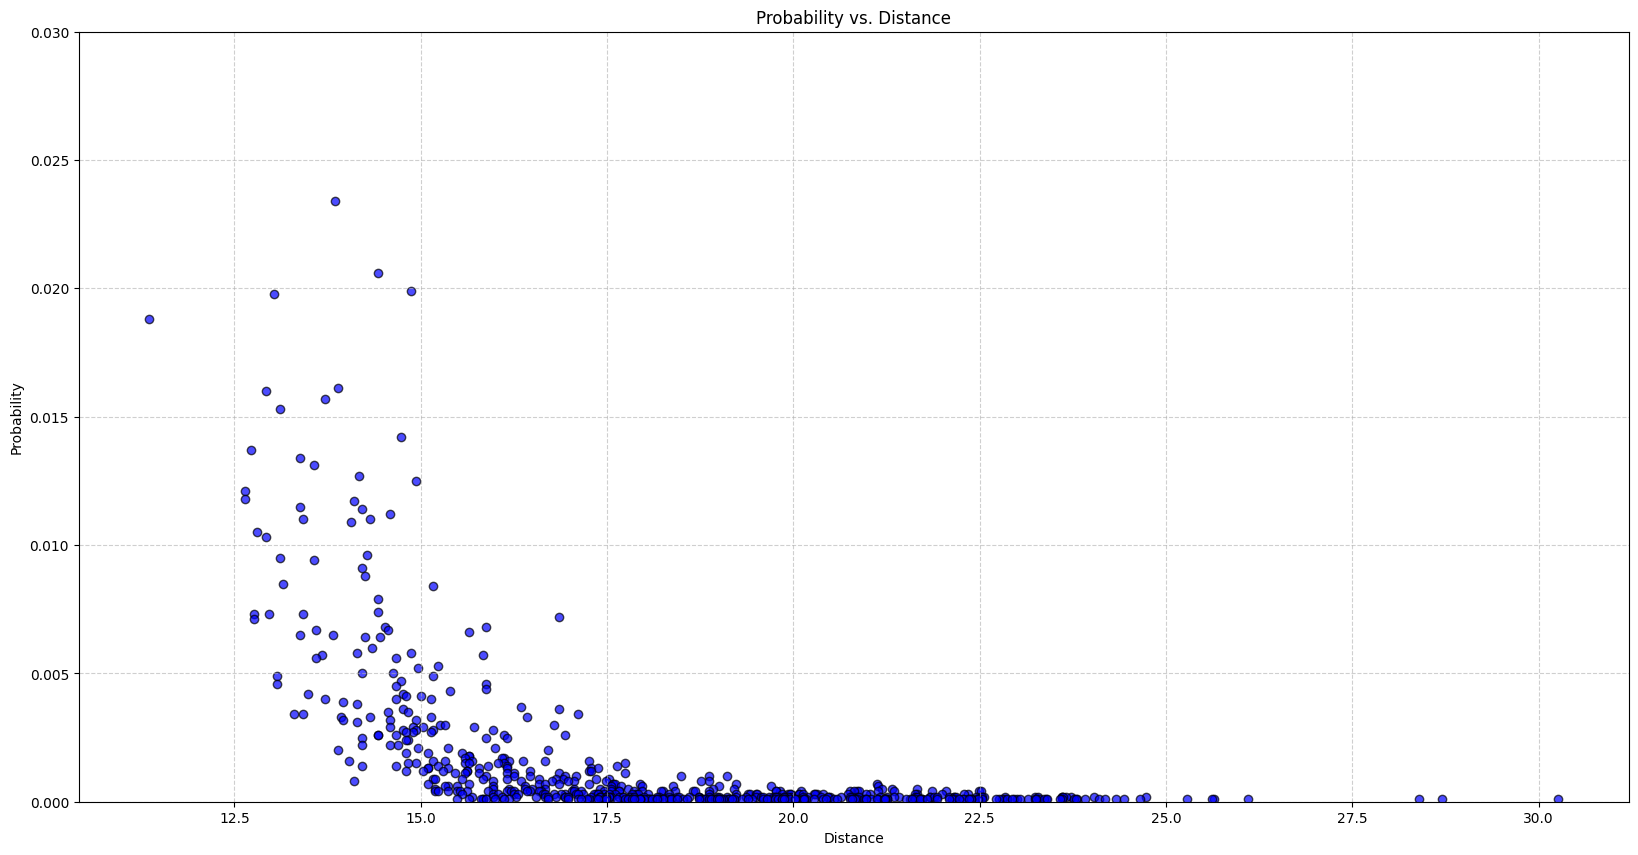

In [36]:
plt.figure(figsize=(20, 10))

# Creating the scatter plot
plt.scatter(distances10, probs10, color='blue', edgecolors='black', alpha=0.7)

# Adding labels and title
plt.xlabel('Distance')
plt.ylabel('Probability')
plt.title('Probability vs. Distance')

# Setting y-axis limit since you mentioned probs are <= 0.2
plt.ylim(0, 0.03) 

plt.grid(True, linestyle='--', alpha=0.6)
plt.show()